# Principal Component Analysis (PCA)
## Dual Implementation:
- SVD Based PCA (Scikit-Learn)
- Eigenvalue Decomposition (Manual)

Dataset: Breast Cancer Wisconsin (Diagnostic)

Goal:
Reduce 30 Features → 2 Principal Components
and compare before vs after dimensionality reduction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer

## Step 1 — Load Dataset
We use a high-dimensional dataset containing 30 features.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape:", X.shape)
X.head()

Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 2 — Standardization
PCA depends on variance, therefore scaling is mandatory.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualization BEFORE PCA
Since data has 30 dimensions, we visualize first two features
just to understand raw distribution.

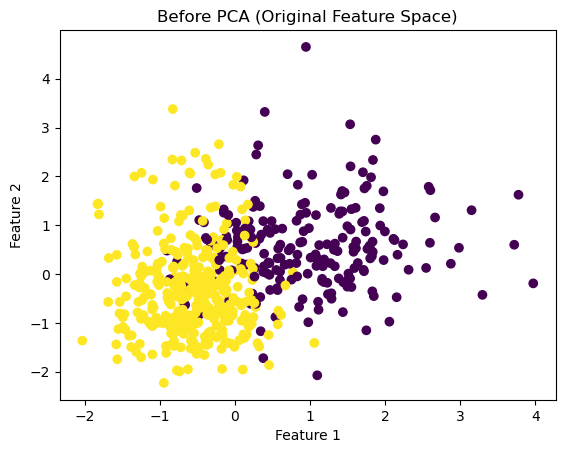

In [4]:
plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Before PCA (Original Feature Space)")
plt.show()

# 🔵 METHOD 1 — PCA using SVD (Scikit-Learn)
Sklearn internally uses Singular Value Decomposition for
numerical stability and efficiency.

In [5]:
pca_svd = PCA(n_components=2)
X_pca_svd = pca_svd.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca_svd.explained_variance_ratio_)

Explained Variance Ratio: [0.44272026 0.18971182]


## Visualization AFTER PCA (SVD)

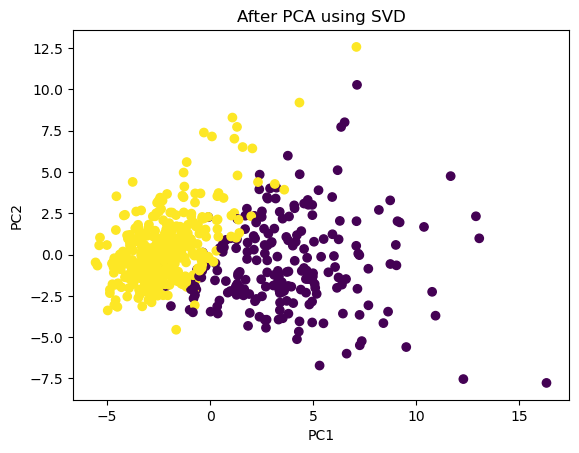

In [6]:
plt.figure()
plt.scatter(X_pca_svd[:,0], X_pca_svd[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("After PCA using SVD")
plt.show()

# 🟣 METHOD 2 — PCA using Eigenvalue Decomposition (Manual)
Steps:
1. Mean Center Data
2. Compute Covariance Matrix
3. Eigenvalues & Eigenvectors
4. Select Top-2 Eigenvectors
5. Project Data

In [7]:
X_centered = X_scaled - np.mean(X_scaled, axis=0)

In [8]:
cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (30, 30)


In [9]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

## Sort Eigenvalues and Select Top 2 Components

In [10]:
sorted_idx = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

top2_vectors = eigenvectors_sorted[:, :2]

In [11]:
X_pca_evd = np.dot(X_centered, top2_vectors)

## Visualization AFTER PCA (EVD)

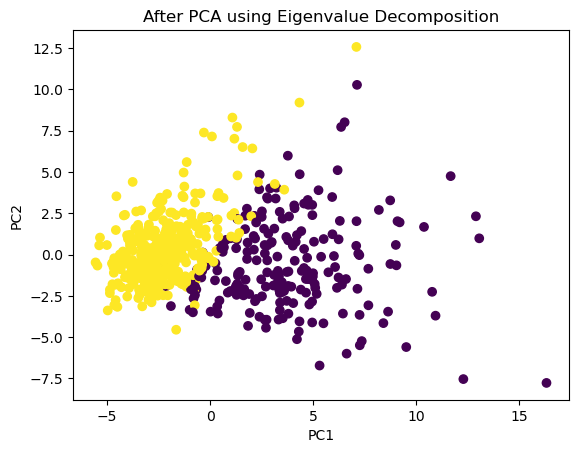

In [12]:
plt.figure()
plt.scatter(X_pca_evd[:,0], X_pca_evd[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("After PCA using Eigenvalue Decomposition")
plt.show()

# 📊 Final Analysis

Observations:
- Before PCA: Data not clearly separable in raw feature space.
- After PCA (SVD): Maximum variance captured in first two components.
- After PCA (EVD): Projection almost identical to SVD result.

Conclusion:
Both methods produce similar principal directions,
but SVD is computationally more stable and preferred in ML pipelines.